ASSIGNMENT: CLUSTER SEGMENTATION WITH K-MEANS
The object is to group customers based on their Annual Income and Spending Score

In [148]:
# Reading the file 'Mail customer_csv' into a pandas DataFrame
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [149]:
# Reading the file 'Mail customer_csv' into a pandas DataFrame
df = pd.read_csv(r"C:\Users\hp\Downloads\Mall_Customers.csv")

In [150]:
# Checking for missing values and data types
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [151]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


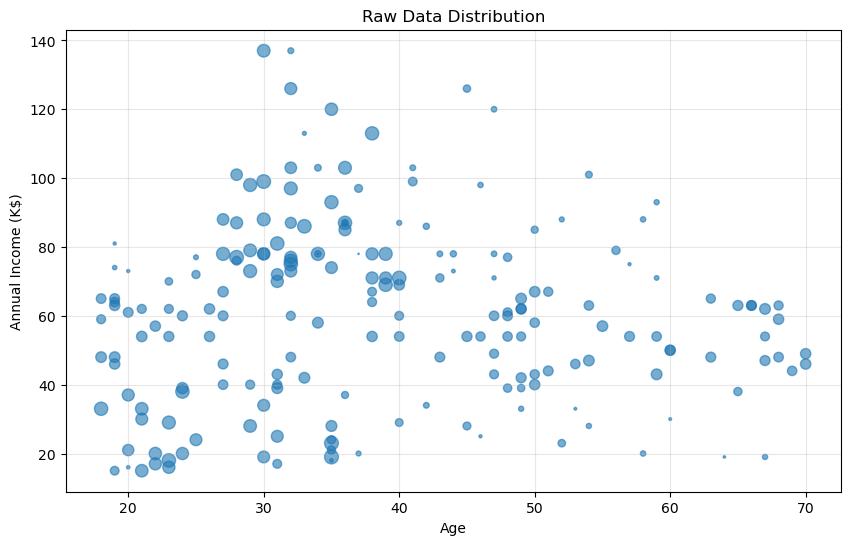

In [152]:
# Visualise the distribution of Age, Annual Income and Spending Score
clustering_features = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
plt.figure(figsize=(10, 6))
plt.scatter(clustering_features['Age'], clustering_features['Annual Income (k$)'], clustering_features['Spending Score (1-100)'],alpha=0.6)
plt.xlabel('Age',)
plt.ylabel('Annual Income (K$)')
plt.title('Raw Data Distribution')
plt.grid(True, alpha=0.3)
plt.show()

Note: Cluster algorithm did not work very well as there is no close relationship between the data points.

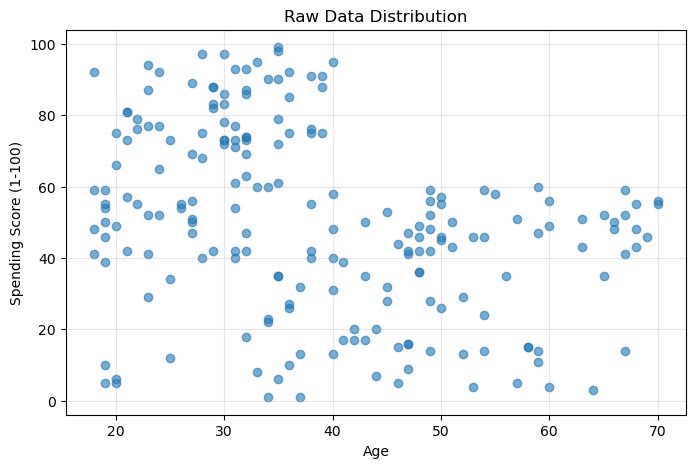

In [93]:
# Visualise the distribution of Age and Spending Score
clustering_features = df[['Age', 'Spending Score (1-100)']]
plt.figure(figsize=(8, 5))
plt.scatter(clustering_features['Age'], clustering_features['Spending Score (1-100)'],alpha=0.6)
plt.xlabel('Age',)
plt.ylabel('Spending Score (1-100)')
plt.title('Raw Data Distribution')
plt.grid(True, alpha=0.3)
plt.show()

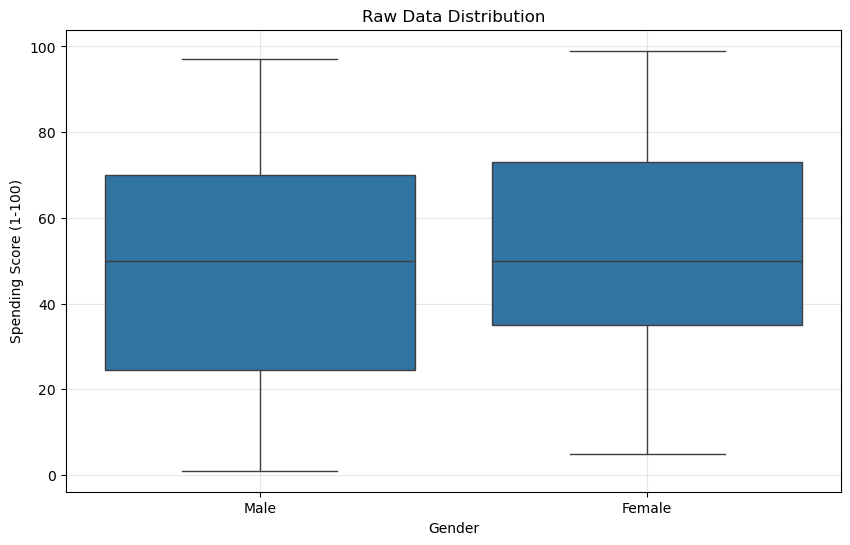

In [109]:
# Visuals the distribution of Gender and Spending Score

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Gender', y='Spending Score (1-100)')
plt.xlabel('Gender',)
plt.ylabel('Spending Score (1-100)')
plt.title('Raw Data Distribution')
plt.grid(True, alpha=0.3)
plt.show()

In [95]:
3. Select features for clustering

In [112]:
clustering_features = df[['Annual Income (k$)', 'Spending Score (1-100)']]
clustering_features.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


4. Determine the optimal number of clusters


In [147]:
# Using Elbow Method; we create a k range to test different numbers of clusters
k_range = range(2,11)
empty_inertias = []

for k in k_range: # we create a KMeans model
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(clustering_features) # Fitting the model
    empty_inertias.append(kmeans.inertia_)
    
    print(f"k={k}: Inertia = {kmeans.inertia_:.2f}")



k=2: Inertia = 181363.60
k=3: Inertia = 106348.37
k=4: Inertia = 73679.79


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


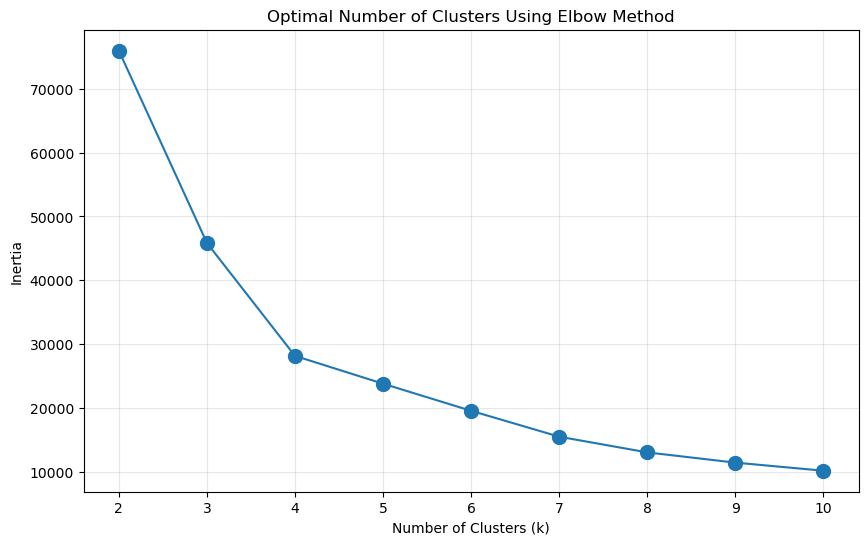

In [97]:
# Plotting the Elbow Curve
plt.figure(figsize=(10,))
plt.plot(k_range, empty_inertias, 'o-', markersize=10)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Optimal Number of Clusters Using Elbow Method')
plt.grid(True, alpha=0.3)
plt.show()

In [98]:
# Using the Silhouette Score Method

In [99]:
silhouette_scores = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(clustering_features)
    silhouette_avg = silhouette_score(clustering_features, cluster_labels) # Silhouette score calculation
    silhouette_scores.append(silhouette_avg)
    print(f"k={k}: Silhouette Score = {silhouette_avg:.3f}")
    

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

k=2: Silhouette Score = 0.469
k=3: Silhouette Score = 0.453
k=4: Silhouette Score = 0.500
k=5: Silhouette Score = 0.445
k=6: Silhouette Score = 0.448
k=7: Silhouette Score = 0.423
k=8: Silhouette Score = 0.428
k=9: Silhouette Score = 0.414
k=10: Silhouette Score = 0.407


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


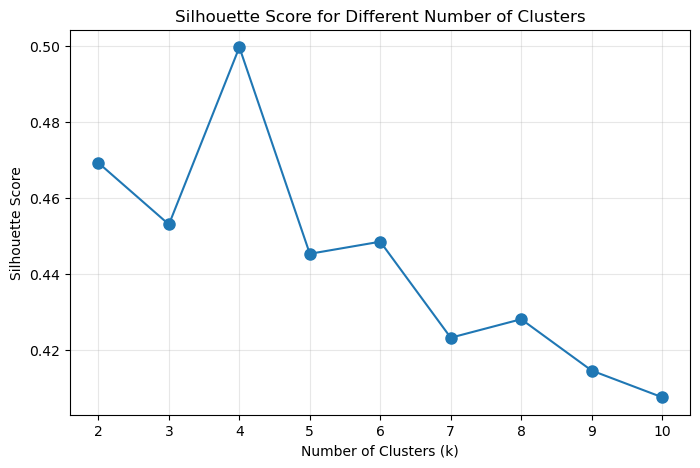

In [100]:
# Plotting the Silhouette score Curve
plt.figure(figsize=(8,5))
plt.plot(k_range, silhouette_scores, 'o-', markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different Number of Clusters')
plt.grid(True, alpha=0.3)
plt.show()
           

5. Build the K-Means Model

In [142]:
final_kmeans = KMeans(n_clusters=4, random_state=42, n_init=10) # Creating the final model
clusters_labels = final_kmeans.fit_predict(clustering_features)


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [143]:
cluster_labels[:10]

array([2, 0, 4, 0, 2, 0, 8, 5, 1, 0], dtype=int32)

In [144]:
# We hereunder added cluster labels to the original datframe and display
# Assigning cluster labels
df_clustered = df.copy()
df_clustered['predicted_cluster'] = cluster_labels

df_clustered["predicted_cluster"].unique()

array([2, 0, 4, 8, 5, 1, 7, 6, 3, 9], dtype=int32)

In [145]:
df_clustered.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),predicted_cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,0
2,3,Female,20,16,6,4
3,4,Female,23,16,77,0
4,5,Female,31,17,40,2


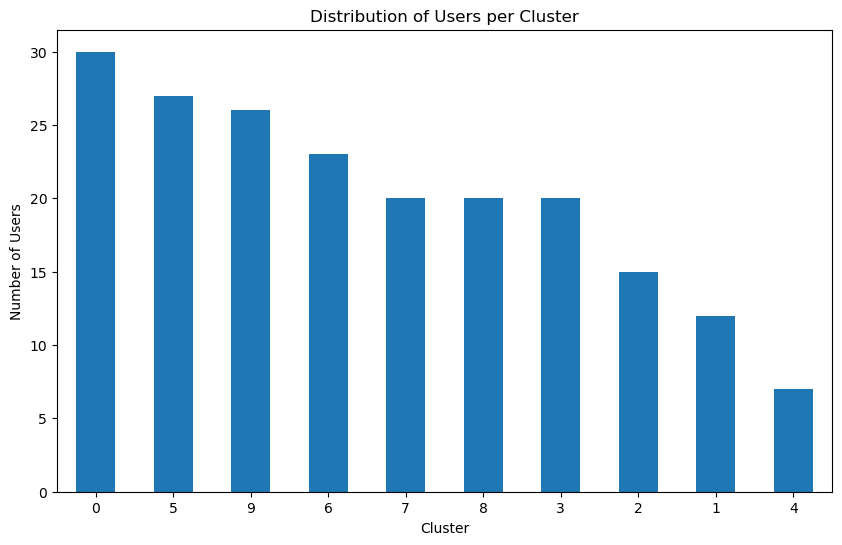

In [146]:
# Visualising the Distribution of Users according to Clusters
plt.figure(figsize=(10, 6))
cluster_counts.plot(kind='bar')
plt.xlabel('Cluster')
plt.ylabel('Number of Users')
plt.title('Distribution of Users per Cluster')
plt.xticks(rotation=0)
plt.show()


From the above, 0 = High Income and High Spender
                2 = Higher Income but Low Spender
                4 = High Income but Very Low Spender